<a href="https://colab.research.google.com/github/vh8432348-ship-it/ITStep-AI/blob/llm/____.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/Used%20Car%20Dataset.csv", index_col="Unnamed: 0")
#df.drop(columns=['car_name', 'registration_year', 'ownsership', 'transmission'], inplace=True)

Дані про ціни вживаних автомобілів у Індії
* car_name - назва авто у форматі 'рік компанія основна назва'
* registration_year - місяць та рік реєстрації
* ownsership - кількість власників у форматі 'Second owner'
* transmission - тип коробки передач
* insurance_validity - тип страховки
* fuel_type - вид палива
* seats - кількість сидінь
* kms_driven - пробіг
* manufacturing_year - рік виробництва, має тип object, потрібно застосувати astype(int)
* mileage(kmpl) - скільки кілометрів проїде за літр палива
* engine(cc) - об'єм двигуна у мл
* max_power(bhp) - потужність у кінських силах
* torque(Nm) - крутний момент двигуна
* price(in lakhs) - ціна у сто тисяч рупій

[Повний аналіз даних](https://www.kaggle.com/code/abdelrasoul/used-cars-prices-prediction)

In [ ]:
df.head()

,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.81,2996.0,2996.0,333.0,63.75
1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0,8.99
2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0,23.75
3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0,13.56
4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0,24.00


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [ ]:
df.shape

(1553, 14)

In [ ]:
df.isna().sum()

,0
car_name,0
registration_year,0
insurance_validity,0
fuel_type,0
seats,0
kms_driven,0
ownsership,0
transmission,0
manufacturing_year,0
mileage(kmpl),3


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

In [ ]:
df.dtypes

,0
car_name,object
registration_year,object
insurance_validity,object
fuel_type,object
seats,int64
kms_driven,int64
ownsership,object
transmission,object
manufacturing_year,object
mileage(kmpl),float64


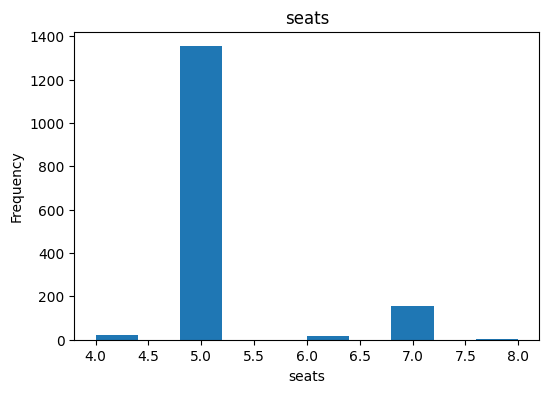

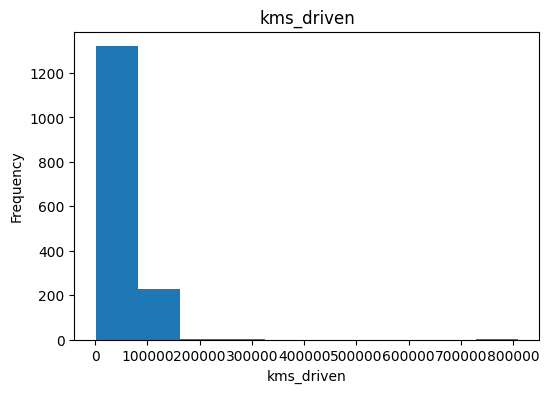

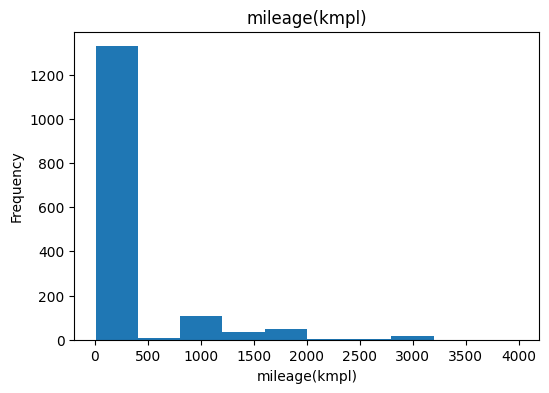

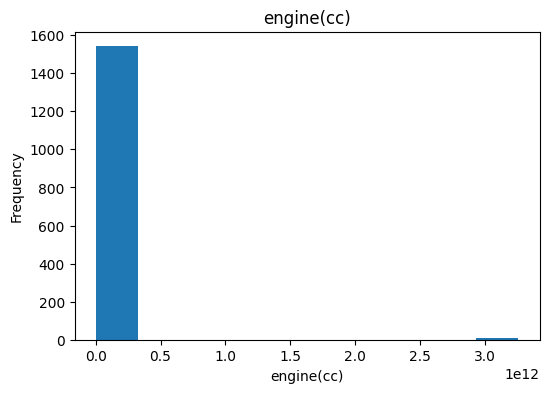

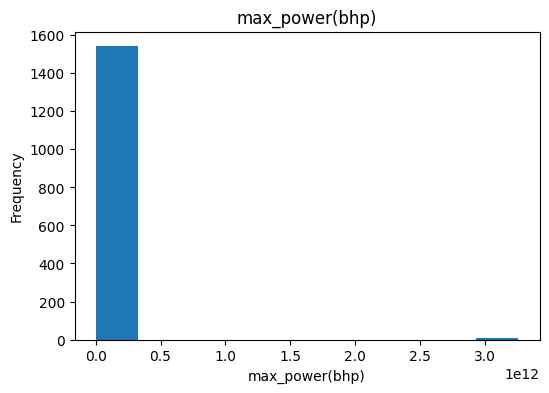

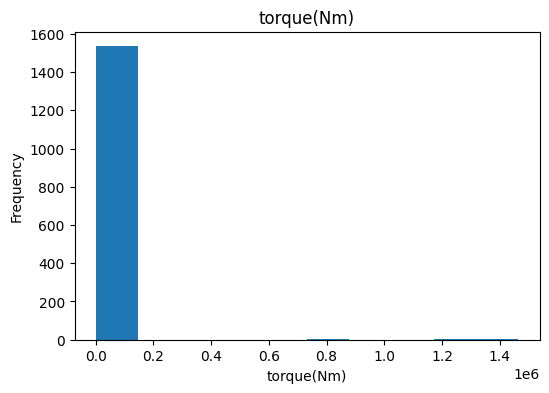

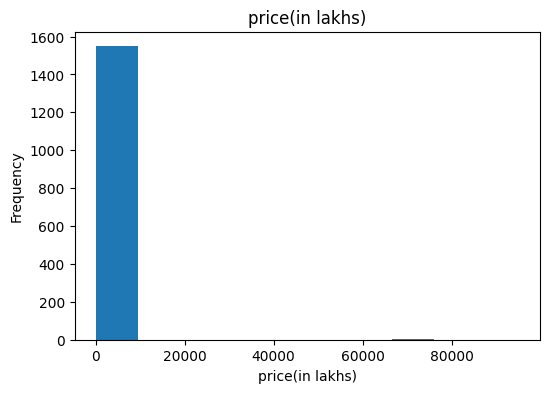

In [ ]:
numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    plt.hist(df[column])
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

In [ ]:
df = df[df['seats'] != 67000]

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

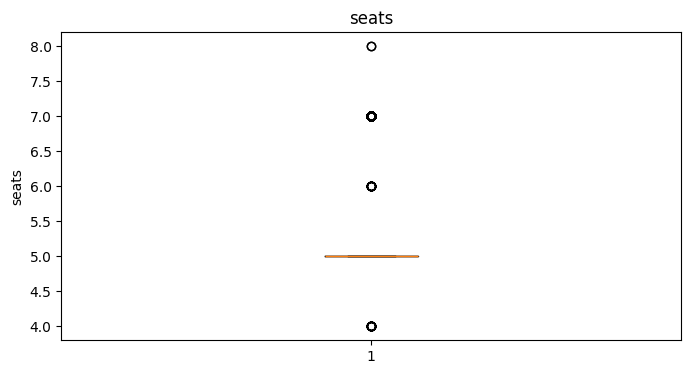

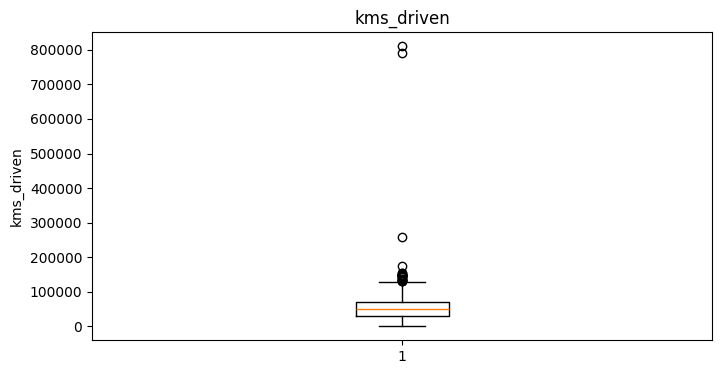

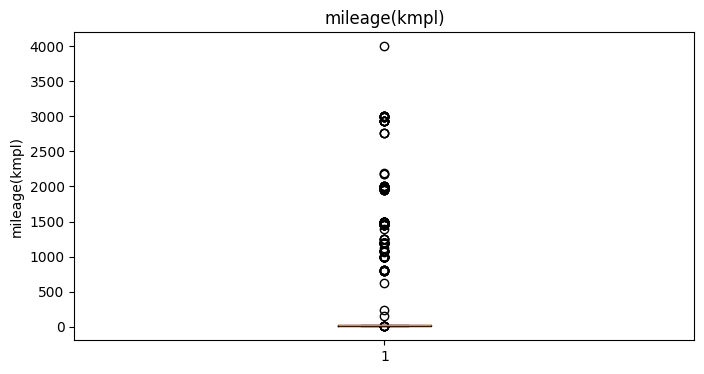

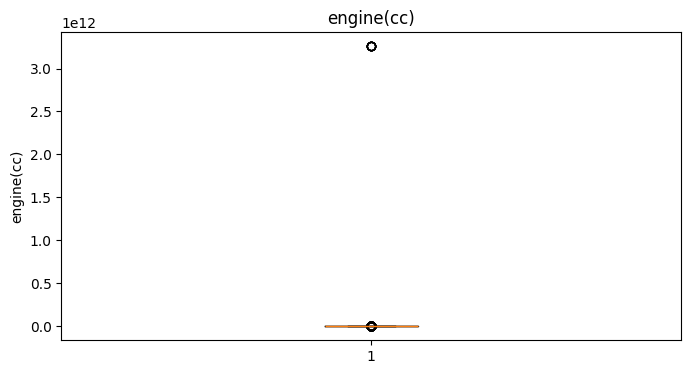

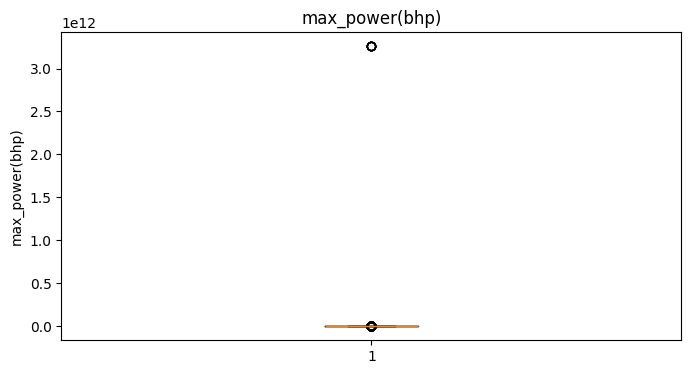

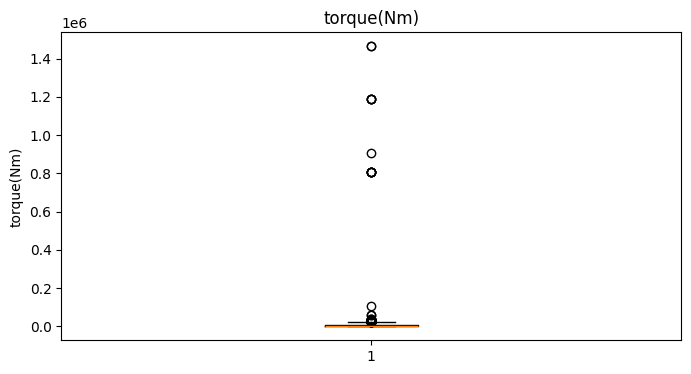

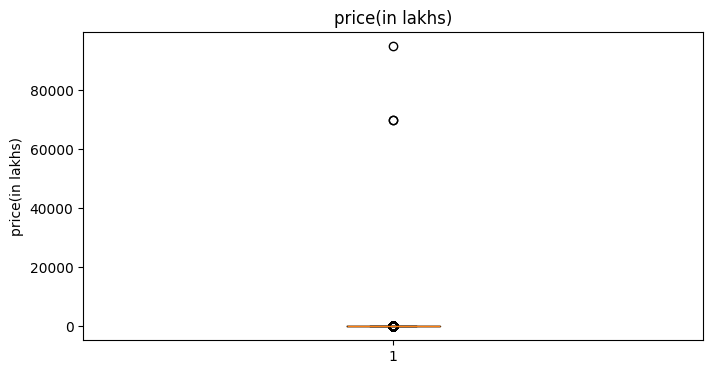

In [ ]:
numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column].dropna())
    plt.title(column)
    plt.ylabel(column)
    plt.show()

In [ ]:
print("seats:", (df['seats'] == 67000).sum())

print("kms_driven:", df['kms_driven'].isin([790000, 810000]).sum())

print("mileage:", (df['mileage(kmpl)'] > 100).sum())

print("engine:", (df['engine(cc)'] > 5000).sum())

print("max_power:", (df['max_power(bhp)'] > 5000).sum())

print("torque:", (df['torque(Nm)'] > 5000).sum())

print("price:", (df['price(in lakhs)'] > 1000).sum())

seats: 0
kms_driven: 2
mileage: 222
engine: 108
max_power: 108
torque: 605
price: 3


# Завдання 4
Створіть Pipeline для обробки даних